In [ ]:
!pip install rasterio tqdm shapely

In [ ]:
# Importações das biblitoecas
import numpy as np
import pandas as pd
import os
from collections import Counter
import rasterio
from rasterio.windows import Window
from shapely.geometry import box
import geopandas as gpd
import random
import warnings
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm import tqdm


In [ ]:
def calculate_simpson_index(patch):
    flat = patch.flatten()
    flat = flat[~np.isnan(flat)]
    if len(flat) == 0:
        return np.nan
    values, counts = np.unique(flat, return_counts=True)
    proportions = counts / counts.sum()
    D = 1 - np.sum(proportions ** 2)
    return D  # já normalizado

In [ ]:
def calculate_shannon_index(patch, nodata_values=None):
    """
    Calcula o índice de diversidade de Shannon para um patch (np.ndarray),
    ignorando valores inválidos como NaN, None ou valores definidos como 'noData'.

    Parâmetros:
    - patch: np.ndarray com os valores do patch
    - nodata_values: lista de valores a ignorar (ex: [0, -9999]); opcional

    Retorna:
    - Índice de Shannon (float)
    """
    # Achatar o array e remover valores NaN ou noData
    values = patch.flatten()

    # Remove NaN
    mask = ~np.isnan(values)

    if nodata_values is not None:
        nodata_values = set(nodata_values)  # torna o teste 'in' O(1)
        mask &= ~np.isin(values, list(nodata_values))  # vetorizado

    valid_values = values[mask]

    if valid_values.size == 0:
        return 0.0

    # np.unique com return_counts é mais eficiente que Counter
    unique_vals, counts = np.unique(valid_values, return_counts=True)
    proportions = counts / counts.sum()

    # Cálculo vetorizado do índice de Shannon
    shannon_index = -np.sum(proportions * np.log(proportions))
    shannon_index_norm = shannon_index / np.log(10)

    return shannon_index_norm

In [ ]:
def sample_random_patches(
    src,
    size_patch_pixels,
    num_patches,
    nodata_values=None #,
    #save_shapefile=True,
    #shapefile_dir="shapefiles",
    #iteration_index=None
):
    """
    Amostra aleatoriamente patches válidos de uma imagem raster georreferenciada e opcionalmente
    salva as localizações dos patches como shapefiles separados por iteração.

    Parâmetros:
    - src: objeto rasterio aberto
    - size_patch_pixels (int): tamanho do patch em pixels (patch quadrado)
    - num_patches (int): número de patches a amostrar
    - nodata_values (list or set): valores a ignorar
    - save_shapefile (bool): se True, salva shapefile
    - shapefile_dir (str): diretório onde os shapefiles serão salvos
    - iteration_index (int): índice da iteração para nomear o arquivo

    Retorna:
    - Lista de np.ndarrays com os patches válidos
    """
    patches = []
    geometries = []

    if nodata_values is None:
        nodata_values = set()
    else:
        nodata_values = set(nodata_values)
    nodata_list = list(nodata_values)

    margin = size_patch_pixels // 2
    max_attempts = num_patches * 3
    attempts = 0
    transform = src.transform

    while len(patches) < num_patches and attempts < max_attempts:
        attempts += 1

        col = random.randint(margin, src.width - margin - 1)
        row = random.randint(margin, src.height - margin - 1)

        # Lê o valor central
        center_window = Window(col, row, 1, 1)
        center_val = src.read(1, window=center_window)[0, 0]
        if np.isnan(center_val) or center_val in nodata_values:
            continue

        # Lê o patch completo
        window = Window(col - margin, row - margin, size_patch_pixels, size_patch_pixels)
        patch = src.read(1, window=window)

        mask_valid = (~np.isnan(patch)) & (~np.isin(patch, nodata_list, assume_unique=True))
        valid_ratio = mask_valid.sum() / patch.size

        if valid_ratio >= 0.9:
            patches.append(patch)

        # Área comentada para salvar unicamente uma iteração

            """if save_shapefile:
                x_min, y_min = rasterio.transform.xy(transform, row + margin, col - margin, offset='ul')
                x_max, y_max = rasterio.transform.xy(transform, row - margin, col + margin, offset='lr')
                geom = box(x_min, y_min, x_max, y_max)
                geometries.append(geom)

    if save_shapefile and geometries:
        os.makedirs(shapefile_dir, exist_ok=True)
        filename = f"patches_iter_{iteration_index:04d}.shp" if iteration_index is not None else "patches.shp"
        shapefile_path = os.path.join(shapefile_dir, filename)
        gdf = gpd.GeoDataFrame(geometry=geometries, crs=src.crs)
        gdf["patch_id"] = range(1, len(gdf) + 1)
        gdf.to_file(shapefile_path)"""

    if len(patches) < num_patches:
        warnings.warn(f"Apenas {len(patches)} patches válidos foram extraídos após {attempts} tentativas.")

    print(f"      Attempts: {attempts}, n_patches: {len(patches)}")
    return patches


In [ ]:
''' def sample_random_patches(band, size_patch_pixels, num_patches, nodata_values=None):
    if nodata_values is None:
        nodata_values = []
    nodata_values = set(nodata_values)

    margin = size_patch_pixels // 2
    height, width = band.shape

    # Máscara de pixels centrais válidos
    #valid_mask = np.ones_like(band, dtype=bool)
    #valid_mask &= ~np.isnan(band)
    #for v in nodata_values:
        #valid_mask &= (band != v)

    # Máscara apenas para garantir que o patch caiba na imagem
    valid_mask = np.ones_like(band, dtype=bool)
    valid_mask[:margin, :] = False
    valid_mask[-margin:, :] = False
    valid_mask[:, :margin] = False
    valid_mask[:, -margin:] = False

    candidates = np.column_stack(np.where(valid_mask))
    # print(f'Patches possíveis:{len(candidates)}')
    np.random.shuffle(candidates)

    patches = []
    attempts = 0
    for row, col in candidates:
        patch = band[row - margin : row + margin + 1,
                     col - margin : col + margin + 1]

        mask_valid = (~np.isnan(patch)) & (~np.isin(patch, list(nodata_values)))
        valid_ratio = mask_valid.sum() / patch.size
        attempts += 1
        if valid_ratio >= 0.9:
            patches.append(patch)

        if len(patches) == num_patches:
            break

    if len(patches) < num_patches:
        warnings.warn(f"Apenas {len(patches)} patches válidos foram extraídos de {num_patches} solicitados.")

    print(f"      Attempts: {attempts}, n_patches: {len(patches)}")
    return patches'''

In [ ]:
# Criar imagem 10x10 com muitos nodata (0) e alguns np.nan
image = np.array([
    [ 1,  1,  1,  1,  1,  1],
    [ 1,  1,  2,  1,  1,  1],
    [ 1,  1,  1,  1,  1,  1],
    [ 1,  1,  1,  1,  1,  1],
    [ 1,  1,  1, 2, 1,  1],
    [ 1,  1,  1,  1,  1,  1]
], dtype="float32")

size_patch = 3
n_patches = 16
nodata_values = [0]

patches = sample_random_patches(image, size_patch, n_patches, nodata_values)

# Mostrar patches extraídos
print(f"\n{len(patches)} patches extraídos (máx. {n_patches}):")
for i, patch in enumerate(patches, 1):
    print(f"\nPatch #{i}:\n{patch}")

In [ ]:
def mean_shannon_index(patches):
    """
    Calcula a média dos índices de Shannon para uma lista de patches válidos.

    Parâmetros:
    - patches (list of np.ndarray): lista de patches válidos

    Retorna:
    - Média dos índices de Shannon (float)
    - Lista dos índices individuais (list of float)
    """
    indices = [calculate_shannon_index(patch) for patch in patches]

    if not indices:
        return np.nan, []

    return np.nanmedian(indices), indices

In [ ]:
def mean_simpson_index(patches):
    """
    Calcula a média dos índices de simpson para uma lista de patches válidos.

    Parâmetros:
    - patches (list of np.ndarray): lista de patches válidos

    Retorna:
    - Média dos índices de simpson (float)
    - Lista dos índices individuais (list of float)
    """
    indices = [calculate_simpson_index(patch) for patch in patches]

    if not indices:
        return np.nan, []

    return np.nanmedian(indices), indices

In [ ]:
def simulate_shannon_sampling(
    band,
    size_patch_pixels,
    num_patches,
    repetitions,
    nodata_values=None
):
    """
    Executa uma simulação com múltiplas amostragens aleatórias para estimar a distribuição
    da média do índice de Shannon em uma imagem raster.

    Parâmetros:
    - tif_path (str): caminho para a imagem .tif
    - size_patch_pixels (float): tamanho do patch em pixels
    - num_patches (int): número de patches por simulação
    - repetitions (int): número de simulações a serem realizadas
    - nodata_values (list): valores considerados como inválidos no raster

    Retorna:
    - Lista com as médias dos índices de Shannon para cada simulação (list of float)
    """
    mean_shannon_values = []

    for i in range(repetitions):
        print(f'    Iteration:{i}...')
        patches = sample_random_patches(
            src=band,
            size_patch_pixels=size_patch_pixels,
            num_patches=num_patches,
            nodata_values=nodata_values
        )

        if len(patches) == 0:
            mean_shannon = np.nan
        else:
            mean_shannon, _ = mean_shannon_index(patches)

        mean_shannon_values.append(mean_shannon)


    return mean_shannon_values


In [ ]:
def simulate_simpson_sampling(
    band,
    size_patch_pixels,
    num_patches,
    repetitions,
    nodata_values=None
):
    """
    Executa uma simulação com múltiplas amostragens aleatórias para estimar a distribuição
    da média do índice de simpsom em uma imagem raster.

    Parâmetros:
    - tif_path (str): caminho para a imagem .tif
    - size_patch_pixels (float): tamanho do patch em pixels
    - num_patches (int): número de patches por simulação
    - repetitions (int): número de simulações a serem realizadas
    - nodata_values (list): valores considerados como inválidos no raster

    Retorna:
    - Lista com as médias dos índices de simpsom para cada simulação (list of float)
    """
    mean_simpson_values = []

    for i in range(repetitions):
        print(f'    Iteration:{i}...')
        patches = sample_random_patches(
            src=band,
            size_patch_pixels=size_patch_pixels,
            num_patches=num_patches,
            nodata_values=nodata_values
        )

        if len(patches) == 0:
            mean_simpson = np.nan
        else:
            mean_simpson, _ = mean_simpson_index(patches)

        mean_simpson_values.append(mean_simpson)


    return mean_simpson_values

In [ ]:
def get_adjusted_patches(size, base_area, min_size, num_patches, proportional_area, proportional_size):
    area = size ** 2
    if proportional_area and proportional_size:
        raise ValueError("Escolha apenas um dos parâmetros de proporcionalidade!")
    elif proportional_area:
        area_factor = base_area / area
        return max(1, int(num_patches * area_factor))
    elif proportional_size:
        size_factor = min_size / size
        return max(1, int(num_patches * size_factor))
    else:
        return num_patches

In [ ]:
def simulate_multiscale_shannon(
    tif_path,
    num_patches,
    min_size,
    max_size,
    step,
    repetitions,
    nodata_values=None,
    show_plot=True,
    verbose=True,
    proportional_area=False,
    proportional_size=False,
    save_csv = False
):
    """
    Executa simulações do índice de Shannon em múltiplas escalas espaciais (tamanho de patch em metros),
    com opção de manter proporcionalidade da área total amostrada entre escalas.

    Parâmetros:
    - tif_path (str): caminho do raster
    - num_patches (int): número de patches na menor escala (min_size)
    - min_size (int): tamanho mínimo do patch (m)
    - max_size (int): tamanho máximo do patch (m)
    - step (int): incremento entre escalas (m)
    - repetitions (int): número de simulações por escala
    - nodata_values (list): valores a ignorar
    - verbose (bool): imprime informações adicionais se True
    - show_plot (bool): exibe o gráfico se True
    - proportional_area (bool): se True, ajusta o número de patches para manter área constante

    Retorna:
    - results (dict): {tamanho_patch: lista de médias de Shannon}
    """

    results = {}
    sizes = list(range(min_size, max_size + 1, step))
    base_area = min_size ** 2  # em m²


    # Estimar o total de iterações antes de iniciar
    estimated_total = 0
    for size in sizes:
        try:
            adjusted_patches = get_adjusted_patches(
    size, base_area, min_size, num_patches, proportional_area, proportional_size)
            estimated_total += repetitions * adjusted_patches
        except ValueError as e:
            print(e)
            return {}

    print(f"\n⚠️ Estimativa total de iterações de amostragem: {estimated_total:,}")
    resposta = input("Para continuar, digite 's': ")
    if resposta.lower() != "s":
      print("❌ Simulação cancelada pelo usuário.")
      return {}


    with rasterio.open(tif_path) as src:
        res_x = src.transform.a
        res_y = -src.transform.e
        assert np.isclose(res_x, res_y), "Os pixels não são quadrados."
        band = src.read(1)

        if verbose:
            print(f'Tamanhos de patch: {sizes}')
            print(f'Resolução (m/pixel): {res_x}')

        for size in sizes:
          size_patch_pixels = int(size / res_x)
          try:
              adjusted_patches = get_adjusted_patches(
    size, base_area, min_size, num_patches, proportional_area, proportional_size
)
          except ValueError as e:
              print(e)
              return {}

          if verbose:
              print(f"🔍 Simulando para patch {size}x{size} m → {adjusted_patches} patches por simulação")

          shannon_means = simulate_shannon_sampling(
              band=src,
              size_patch_pixels=size_patch_pixels,
              num_patches=adjusted_patches,
              repetitions=repetitions,
              nodata_values=nodata_values
          )

          results[size] = shannon_means



    if show_plot:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=[results[size] for size in sizes])
        plt.xticks(ticks=np.arange(len(sizes)), labels=[f"{s}" for s in sizes])
        plt.xlabel("Landscape extent (m)")
        plt.ylabel("SHDI median")
        plt.title("Distribution of Shannon index medians")

        mean_values = [np.nanmean(results[size]) for size in sizes]
        std_values = [np.nanstd(results[size]) for size in sizes]
        plt.plot(np.arange(len(sizes)), mean_values, color='red', marker='o', linestyle='-', label='Mean')
        plt.legend()
        plt.tight_layout()
        plt.show()

    if save_csv:
      df_results = pd.DataFrame.from_dict(results)

      # Save the DataFrame to a CSV file
      df_results.to_csv('simulation_results.csv', index=False)
      print("Results saved to simulation_results.csv")

    return results


In [ ]:
def simulate_multiscale_simpson(
    tif_path,
    num_patches,
    min_size,
    max_size,
    step,
    repetitions,
    nodata_values=None,
    show_plot=True,
    verbose=True,
    proportional_area=False,
    proportional_size=False,
    save_csv = False
):
    """
    Executa simulações do índice de simpson em múltiplas escalas espaciais (tamanho de patch em metros),
    com opção de manter proporcionalidade da área total amostrada entre escalas.

    Parâmetros:
    - tif_path (str): caminho do raster
    - num_patches (int): número de patches na menor escala (min_size)
    - min_size (int): tamanho mínimo do patch (m)
    - max_size (int): tamanho máximo do patch (m)
    - step (int): incremento entre escalas (m)
    - repetitions (int): número de simulações por escala
    - nodata_values (list): valores a ignorar
    - verbose (bool): imprime informações adicionais se True
    - show_plot (bool): exibe o gráfico se True
    - proportional_area (bool): se True, ajusta o número de patches para manter área constante

    Retorna:
    - results (dict): {tamanho_patch: lista de médias de Shannon}
    """

    results = {}
    sizes = list(range(min_size, max_size + 1, step))
    base_area = min_size ** 2  # em m²


    # Estimar o total de iterações antes de iniciar
    estimated_total = 0
    for size in sizes:
        try:
            adjusted_patches = get_adjusted_patches(
    size, base_area, min_size, num_patches, proportional_area, proportional_size)
            estimated_total += repetitions * adjusted_patches
        except ValueError as e:
            print(e)
            return {}

    print(f"\n⚠️ Estimativa total de iterações de amostragem: {estimated_total:,}")
    resposta = input("Para continuar, digite 's': ")
    if resposta.lower() != "s":
      print("❌ Simulação cancelada pelo usuário.")
      return {}


    with rasterio.open(tif_path) as src:
        res_x = src.transform.a
        res_y = -src.transform.e
        assert np.isclose(res_x, res_y), "Os pixels não são quadrados."
        band = src.read(1)

        if verbose:
            print(f'Tamanhos de patch: {sizes}')
            print(f'Resolução (m/pixel): {res_x}')

        for size in sizes:
          size_patch_pixels = int(size / res_x)
          try:
              adjusted_patches = get_adjusted_patches(
    size, base_area, min_size, num_patches, proportional_area, proportional_size
)
          except ValueError as e:
              print(e)
              return {}

          if verbose:
              print(f"🔍 Simulando para patch {size}x{size} m → {adjusted_patches} patches por simulação")

          simpson_means = simulate_simpson_sampling(
              band=src,
              size_patch_pixels=size_patch_pixels,
              num_patches=adjusted_patches,
              repetitions=repetitions,
              nodata_values=nodata_values
          )

          results[size] = simpson_means


    if show_plot:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=[results[size] for size in sizes])
        plt.xticks(ticks=np.arange(len(sizes)), labels=[f"{s}" for s in sizes])
        plt.xlabel("Tamanho do patch (m)")
        plt.ylabel("Medianas do índice de Simpson")
        plt.title("Distribuição das medianas do índice de Simpson")

        mean_values = [np.nanmean(results[size]) for size in sizes]
        std_values = [np.nanstd(results[size]) for size in sizes]
        plt.plot(np.arange(len(sizes)), mean_values, color='red', marker='o', linestyle='-', label='Média')
        plt.legend()
        plt.tight_layout()
        plt.show()

    if save_csv:
      df_results = pd.DataFrame.from_dict(results)

      # Save the DataFrame to a CSV file
      df_results.to_csv('simulation_results.csv', index=False)
      print("Results saved to simulation_results.csv")

    return results


⚠️ Estimativa total de iterações de amostragem: 100,000
Para continuar, digite 's': s
Tamanhos de patch: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
Resolução (m/pixel): 10.0
🔍 Simulando para patch 1000x1000 m → 100 patches por simulação
    Iteration:0...
      Attempts: 168, n_patches: 100
    Iteration:1...
      Attempts: 152, n_patches: 100
    Iteration:2...
      Attempts: 142, n_patches: 100
    Iteration:3...
      Attempts: 161, n_patches: 100
    Iteration:4...
      Attempts: 149, n_patches: 100
    Iteration:5...
      Attempts: 138, n_patches: 100
    Iteration:6...
      Attempts: 139, n_patches: 100
    Iteration:7...
      Attempts: 141, n_patches: 100
    Iteration:8...
      Attempts: 142, n_patches: 100
    Iteration:9...
      Attempts: 141, n_patches: 100
    Iteration:10...
      Attempts: 146, n_patches: 100
    Iteration:11...
      Attempts: 145, n_patches: 100
    Iteration:12...
      Attempts: 136, n_patches: 100
    Iteration:13...
     

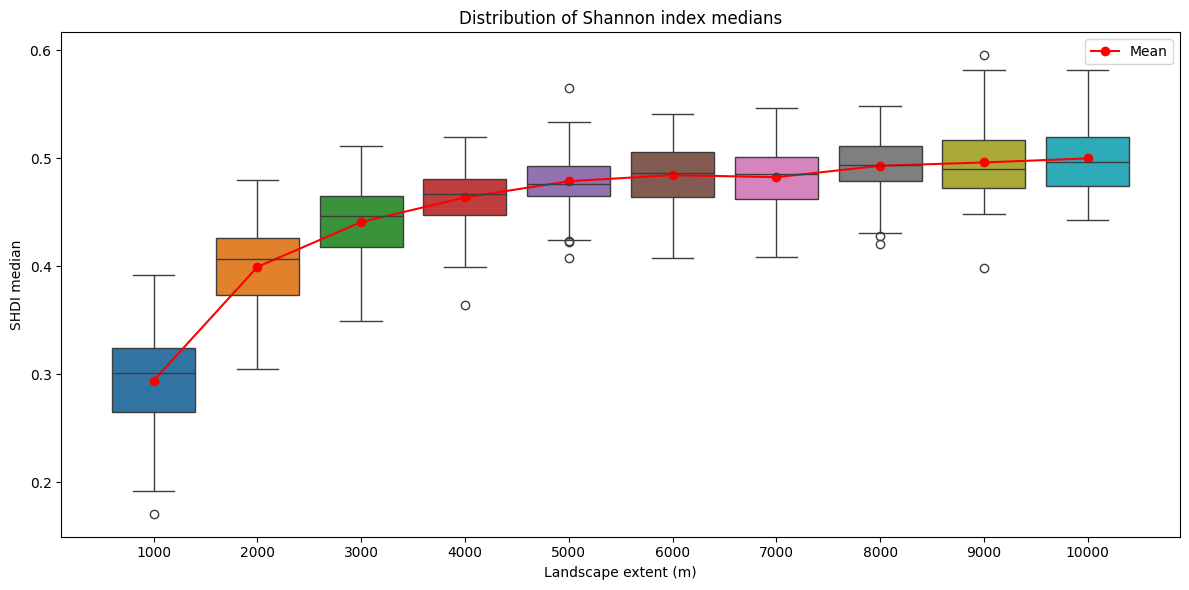

In [ ]:
results = simulate_multiscale_shannon(
    tif_path="/content/mojui.tif",
    min_size=1000,           # tamanho mínimo do patch em pixels
    max_size=10000,           # tamanho máximo do patch
    step=1000,                # incremento linear de tamanho
    repetitions= 100,       # número de simulações por tamanho
    num_patches= 100,       # patches por simulação
    proportional_area= False,
    proportional_size= False,
    nodata_values=[0, -128]
)


⚠️ Estimativa total de iterações de amostragem: 585,600
Para continuar, digite 's': s
Tamanhos de patch: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
Resolução (m/pixel): 10.0
🔍 Simulando para patch 1000x1000 m → 2000 patches por simulação
    Iteration:0...
      Attempts: 2948, n_patches: 2000
    Iteration:1...
      Attempts: 2886, n_patches: 2000
    Iteration:2...
      Attempts: 2884, n_patches: 2000
    Iteration:3...
      Attempts: 2962, n_patches: 2000
    Iteration:4...
      Attempts: 2814, n_patches: 2000
    Iteration:5...
      Attempts: 2950, n_patches: 2000
    Iteration:6...
      Attempts: 2916, n_patches: 2000
    Iteration:7...
      Attempts: 2863, n_patches: 2000
    Iteration:8...
      Attempts: 2854, n_patches: 2000
    Iteration:9...
      Attempts: 2876, n_patches: 2000
    Iteration:10...
      Attempts: 2900, n_patches: 2000
    Iteration:11...
      Attempts: 2912, n_patches: 2000
    Iteration:12...
      Attempts: 2913, n_patches: 200

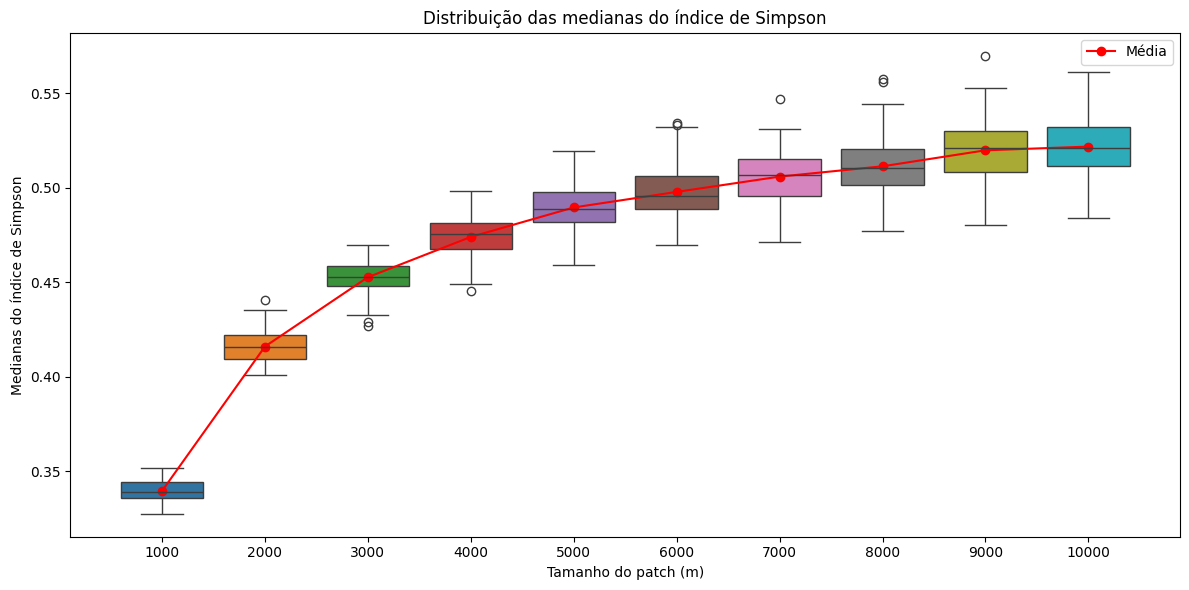

In [ ]:
results = simulate_multiscale_simpson(
    tif_path="/content/mojui.tif",
    min_size=1000,           # tamanho mínimo do patch em pixels
    max_size=10000,           # tamanho máximo do patch
    step=1000,                # incremento linear de tamanho
    repetitions= 100,       # número de simulações por tamanho
    num_patches= 2000,       # patches por simulação
    proportional_area= False,
    proportional_size= True,
    nodata_values=[0, -128]
)

In [ ]:
# Caminho para seu arquivo raster (.tif)
raster_path = '/content/mojui.tif'  # Substitua com o nome do seu arquivo

# Abrir o raster
with rasterio.open(raster_path) as src:
    band = src.read(1)  # Lê a primeira banda (modifique se precisar)
    nodata = src.nodata

# Flatten + remover valores NoData
flattened = band.flatten()

if nodata is not None:
    flattened = flattened[flattened != nodata]
else:
    flattened = flattened[~np.isnan(flattened)]  # Caso o raster use NaN

# Extrair valores únicos
unique_values = np.unique(flattened)

# Mostrar resultado
print(f"Número de valores únicos: {len(unique_values)}")
print("Valores únicos:")
print(unique_values)

Número de valores únicos: 11
Valores únicos:
[ 0  1  2 10 11 14 15 17 20 22 23]
